In [1]:
import math
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import pandas as pd

import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from torchvision.datasets import EMNIST

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
device: cpu
torch: 2.10.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
DEFAULT_NUM_WORKERS = 0
BATCH_SIZE = 128
VAL_RATIO = 0.2
RANDOM_SEED = 42

def load_emnist_balanced():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_full = EMNIST(
        root='./data',
        split='balanced',
        train=True,
        download=True,
        transform=transform
    )

    test_ds = EMNIST(
        root='./data',
        split='balanced',
        train=False,
        download=True,
        transform=transform
    )

    print("EMNIST(split='balanced') загружен:")
    print(f"Train full: {len(train_full)} изображений")
    print(f"Test: {len(test_ds)} изображений")
    print(f"Количество классов: {len(train_full.classes)}")

    return train_full, test_ds

def make_loaders(ds_train_full, ds_test, batch_size: int = BATCH_SIZE, val_ratio: float = VAL_RATIO, seed: int = RANDOM_SEED):
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    print(f"Разбиение dataset:")
    print(f"Всего train: {n_total}")
    print(f"Train: {n_train} ({n_train/n_total*100}%)")
    print(f"Val: {n_val} ({n_val/n_total*100}%)")

    #воспроизводимость
    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(
        ds_train_full,
        [n_train, n_val],
        generator=gen
    )

    #DataLoader
    train_loader = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader

In [4]:
train_full, test_ds = load_emnist_balanced()

#DataLoader
train_loader, val_loader, test_loader = make_loaders(
    ds_train_full=train_full,
    ds_test=test_ds,
    batch_size=128,
    val_ratio=0.2,
    seed=42
)

#Sanity check
x, y = next(iter(train_loader))
print(f"\nSanity check:")
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"x min: {x.min().item()}")
print(f"x max: {x.max().item()}")

#Константы для модели
INPUT_DIM = 28 * 28  # 784 - для Flatten слоя
NUM_CLASSES = 47     # количество классов EMNIST balanced

100.0%


EMNIST(split='balanced') загружен:
Train full: 112800 изображений
Test: 18800 изображений
Количество классов: 47
Разбиение dataset:
Всего train: 112800
Train: 90240 (80.0%)
Val: 22560 (20.0%)

Sanity check:
x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])
x min: -1.0
x max: 1.0


In [5]:
class MLP(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()
        c, h, w = input_shape
        in_features = c * h * w

        act_layer = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "gelu": nn.GELU,
        }.get(activation.lower(), nn.ReLU)

        layers: List[nn.Module] = [nn.Flatten()]

        prev = in_features
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))
            layers.append(act_layer())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hs

        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def grad_global_norm(parameters) -> float:
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return math.sqrt(total_norm_sq)

In [7]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    grad_norms_before = []
    grad_norms_after = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        # иногда на очень агрессивных настройках бывает NaN – делаем мягкую защиту
        if not torch.isfinite(loss):
            continue

        loss.backward()

        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)

        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    avg_loss = float(total_loss / max(1, n))
    avg_acc = float(total_acc / max(1, n))

    return avg_loss, avg_acc


In [8]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return float(total_loss / max(1, n)), float(total_acc / max(1, n))

def plot_history(history: Dict[str, List[float]], title: str = ""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(list(epochs), history["train_loss"], label="train_loss")
    plt.plot(list(epochs), history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title or "Loss curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(list(epochs), history["train_acc"], label="train_acc")
    plt.plot(list(epochs), history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title or "Accuracy curves")
    plt.legend()
    plt.show()

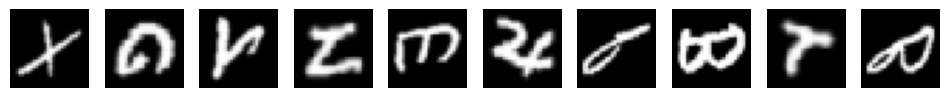

In [9]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [10]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [11]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [12]:
def get_best_metrics(history):
    """Извлекает лучшие метрики из истории"""
    best_epoch = np.argmax(history['val_acc'])
    return {
        'best_val_acc': history['val_acc'][best_epoch],
        'best_val_loss': history['val_loss'][best_epoch],
        'epochs_trained': len(history['val_acc'])
    }

epoch 01/20 | train loss=1.3389, acc=0.6199 | val loss=0.8915, acc=0.7302
epoch 02/20 | train loss=0.7550, acc=0.7660 | val loss=0.7070, acc=0.7759
epoch 03/20 | train loss=0.6161, acc=0.8010 | val loss=0.6122, acc=0.8060
epoch 04/20 | train loss=0.5444, acc=0.8198 | val loss=0.5712, acc=0.8188
epoch 05/20 | train loss=0.5036, acc=0.8314 | val loss=0.5547, acc=0.8186
epoch 06/20 | train loss=0.4710, acc=0.8395 | val loss=0.5380, acc=0.8261
epoch 07/20 | train loss=0.4457, acc=0.8468 | val loss=0.5218, acc=0.8312
epoch 08/20 | train loss=0.4250, acc=0.8515 | val loss=0.5536, acc=0.8193
epoch 09/20 | train loss=0.4085, acc=0.8556 | val loss=0.5110, acc=0.8337
epoch 10/20 | train loss=0.3926, acc=0.8594 | val loss=0.5306, acc=0.8281
epoch 11/20 | train loss=0.3770, acc=0.8641 | val loss=0.5252, acc=0.8295
epoch 12/20 | train loss=0.3647, acc=0.8677 | val loss=0.5238, acc=0.8318
epoch 13/20 | train loss=0.3541, acc=0.8696 | val loss=0.5209, acc=0.8341
epoch 14/20 | train loss=0.3423, acc=0

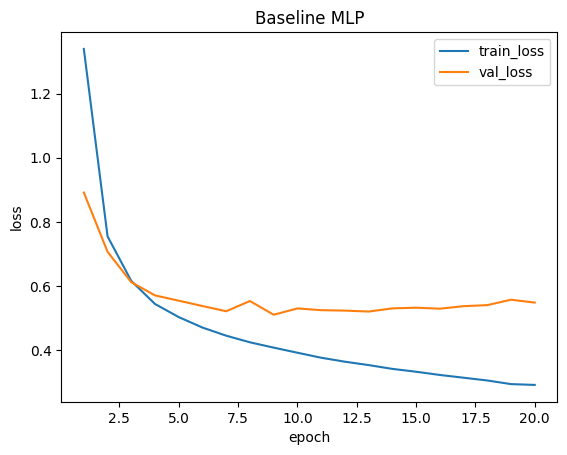

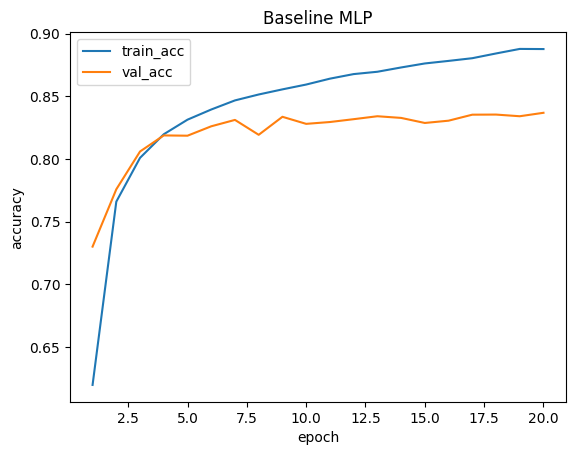

In [13]:
all_results = []

baseline = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_e1 = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e1, title="Baseline MLP")

In [16]:
metrics_e1 = get_best_metrics(history_e1)
all_results.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128)',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e1['epochs_trained'],
    'best_val_accuracy': metrics_e1['best_val_acc'],
    'best_val_loss': metrics_e1['best_val_loss']
})

print(f"E1 best val_acc: {metrics_e1['best_val_acc']:.4f}")

df = pd.DataFrame(all_results)
df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

E1 best val_acc: 0.8369

Результаты сохранены в artifacts/runs.csv


epoch 01/20 | train loss=1.6771, acc=0.5185 | val loss=0.9417, acc=0.7188
epoch 02/20 | train loss=1.0818, acc=0.6692 | val loss=0.7652, acc=0.7637
epoch 03/20 | train loss=0.9548, acc=0.7051 | val loss=0.6857, acc=0.7859
epoch 04/20 | train loss=0.8940, acc=0.7203 | val loss=0.6553, acc=0.7932
epoch 05/20 | train loss=0.8509, acc=0.7317 | val loss=0.6231, acc=0.8019
epoch 06/20 | train loss=0.8137, acc=0.7402 | val loss=0.5952, acc=0.8063
epoch 07/20 | train loss=0.8005, acc=0.7440 | val loss=0.5877, acc=0.8074
epoch 08/20 | train loss=0.7754, acc=0.7501 | val loss=0.5686, acc=0.8113
epoch 09/20 | train loss=0.7609, acc=0.7528 | val loss=0.5623, acc=0.8173
epoch 10/20 | train loss=0.7491, acc=0.7582 | val loss=0.5506, acc=0.8190
epoch 11/20 | train loss=0.7370, acc=0.7595 | val loss=0.5445, acc=0.8189
epoch 12/20 | train loss=0.7239, acc=0.7646 | val loss=0.5382, acc=0.8236
epoch 13/20 | train loss=0.7189, acc=0.7648 | val loss=0.5321, acc=0.8236
epoch 14/20 | train loss=0.7129, acc=0

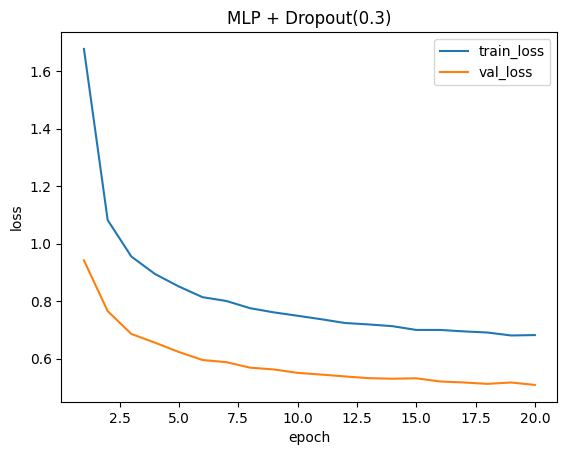

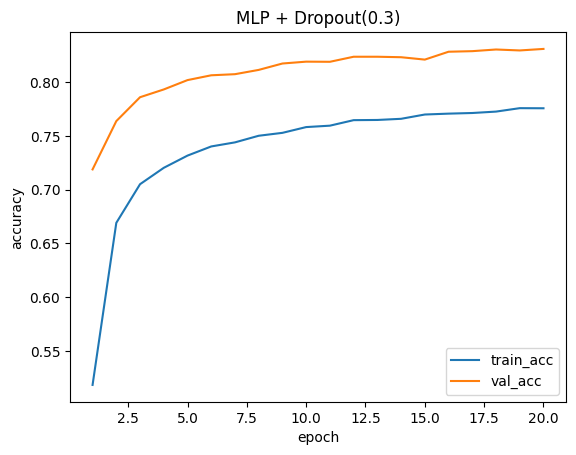

In [18]:
set_seed(42)
dropout_model = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")

In [ ]:
all_results_e2 = []
metrics_e2 = get_best_metrics(history_dropout)
all_results_e2.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), dropout=0.3',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e2['epochs_trained'],
    'best_val_accuracy': metrics_e2['best_val_acc'],
    'best_val_loss': metrics_e2['best_val_loss']
})

print(f"E2 best val_acc: {metrics_e2['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_e2)
df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

In [ ]:
set_seed(42)
bn_model = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")

In [ ]:
all_results_e3 = []
metrics_e3 = get_best_metrics(history_bn)
all_results_e3.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), BatchNorm',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e3['epochs_trained'],
    'best_val_accuracy': metrics_e3['best_val_acc'],
    'best_val_loss': metrics_e3['best_val_loss']
})

print(f"E3 best val_acc: {metrics_e3['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_e3)
df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

In [ ]:
model_o1 = MLP(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    hidden_sizes=[256, 128],
    use_batchnorm=True,
    dropout=0.3
).to(device)

optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=6,
    early_stopping=False
)

plot_history(history_o1, title="O1: LR too high (0.1)")

In [ ]:
model_o2 = MLP(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    hidden_sizes=[256, 128],
    activation="relu",
    use_batchnorm=True,
    dropout=0.3
).to(device)

optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)  # ❌ слишком маленький

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=6,
    verbose=True
)

plot_history(history_o2, title="O2: LR too low (1e-5)")